In [1]:
# Check if GPU is available
import torch

if torch.cuda.is_available():
    print("GPU is available")
else:
    print("Running on CPU")

GPU is available


In [2]:
# Install required libraries
!pip install opencv-python matplotlib pycocotools tqdm

In [3]:
# Basic libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# COCO tools
from pycocotools.coco import COCO

# Utility
from tqdm import tqdm

In [4]:
# Create dataset directory
os.makedirs("coco", exist_ok=True)

# Download validation images
!wget -c http://images.cocodataset.org/zips/val2017.zip -P coco/

# Download annotations
!wget -c http://images.cocodataset.org/annotations/annotations_trainval2017.zip -P coco/

--2026-03-02 11:24:24--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.83.164, 54.231.229.129, 16.15.195.229, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.83.164|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘coco/val2017.zip’

val2017.zip         100%[===================>] 777.80M  47.1MB/s    in 16s     

2026-03-02 11:24:39 (50.1 MB/s) - ‘coco/val2017.zip’ saved [815585330/815585330]

--2026-03-02 11:24:39--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.187.122, 54.231.199.209, 3.5.30.244, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.187.122|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘coco/annotations_trainval2017.zip’

ann

In [5]:
# Unzip images
!unzip -q coco/val2017.zip -d coco/

# Unzip annotations
!unzip -q coco/annotations_trainval2017.zip -d coco/

In [6]:
# Paths
IMAGE_DIR = "coco/val2017"
ANNOTATION_FILE = "coco/annotations/instances_val2017.json"

print("Image directory:", IMAGE_DIR)
print("Annotation file:", ANNOTATION_FILE)

Image directory: coco/val2017
Annotation file: coco/annotations/instances_val2017.json


In [7]:
# Load COCO dataset
coco = COCO(ANNOTATION_FILE)

# Number of images and categories
print("Total Images:", len(coco.imgs))
print("Total Categories:", len(coco.cats))

loading annotations into memory...
Done (t=0.50s)
creating index...
index created!
Total Images: 5000
Total Categories: 80


In [8]:
# Print first 10 category names
categories = coco.loadCats(coco.getCatIds())
category_names = [cat['name'] for cat in categories]

print("Sample Categories:")
print(category_names[:10])

Sample Categories:
['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


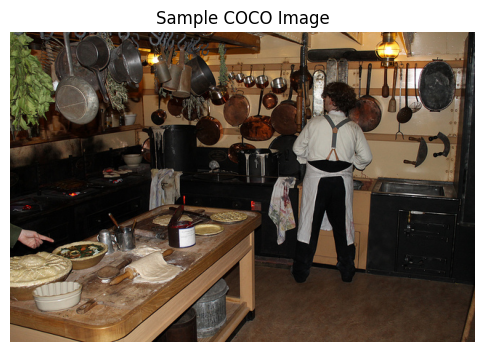

In [9]:
# Get a random image ID
img_id = list(coco.imgs.keys())[0]

# Load image info
img_info = coco.loadImgs(img_id)[0]

# Read image using OpenCV
img_path = os.path.join(IMAGE_DIR, img_info['file_name'])
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display image
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Sample COCO Image")
plt.show()

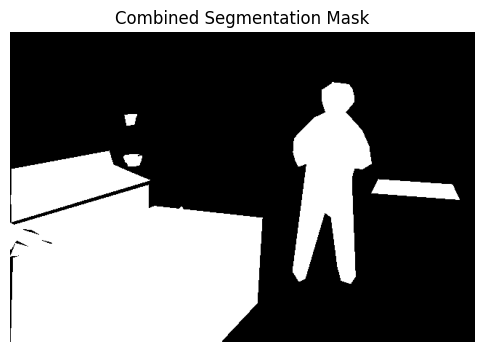

In [10]:
# Get annotations for the image
ann_ids = coco.getAnnIds(imgIds=img_id)
annotations = coco.loadAnns(ann_ids)

# Create empty mask
mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

# Combine all object masks
for ann in annotations:
    mask = np.maximum(mask, coco.annToMask(ann))

# Display mask
plt.figure(figsize=(6,6))
plt.imshow(mask, cmap='gray')
plt.axis("off")
plt.title("Combined Segmentation Mask")
plt.show()

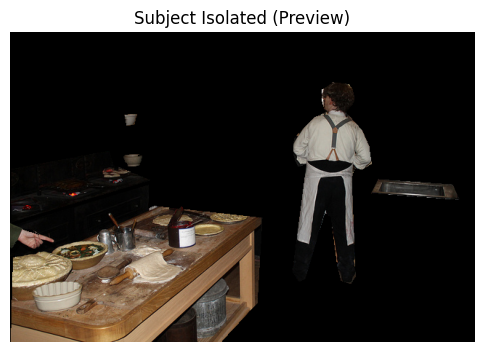

In [11]:
# Apply mask to image
isolated_subject = image.copy()
isolated_subject[mask == 0] = 0  # Background black

# Display isolated subject
plt.figure(figsize=(6,6))
plt.imshow(isolated_subject)
plt.axis("off")
plt.title("Subject Isolated (Preview)")
plt.show()

In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from tqdm import tqdm

In [13]:
# Paths
IMAGE_DIR = "coco/val2017"
ANNOTATION_FILE = "coco/annotations/instances_val2017.json"

# Load COCO
coco = COCO(ANNOTATION_FILE)

print("Dataset loaded successfully")

loading annotations into memory...
Done (t=0.89s)
creating index...
index created!
Dataset loaded successfully


In [14]:
# Image size for model input
IMG_HEIGHT = 256
IMG_WIDTH = 256

In [15]:
def load_image_and_mask(img_id):
    """
    Loads an image and its corresponding binary segmentation mask
    """
    # Load image info
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMAGE_DIR, img_info['file_name'])

    # Read image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Create empty mask
    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

    # Load annotations
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    # Combine all object masks into one
    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))

    return image, mask

In [16]:
def resize_image_mask(image, mask):
    # Resize image
    image_resized = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))

    # Resize mask (important: INTER_NEAREST)
    mask_resized = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)

    return image_resized, mask_resized

In [17]:
def normalize_image_mask(image, mask):
    # Normalize image to range [0,1]
    image = image.astype(np.float32) / 255.0

    # Convert mask to binary (0 or 1)
    mask = (mask > 0).astype(np.float32)

    return image, mask

In [18]:
def preprocess_sample(img_id):
    # Load
    image, mask = load_image_and_mask(img_id)

    # Resize
    image, mask = resize_image_mask(image, mask)

    # Normalize & binarize
    image, mask = normalize_image_mask(image, mask)

    return image, mask

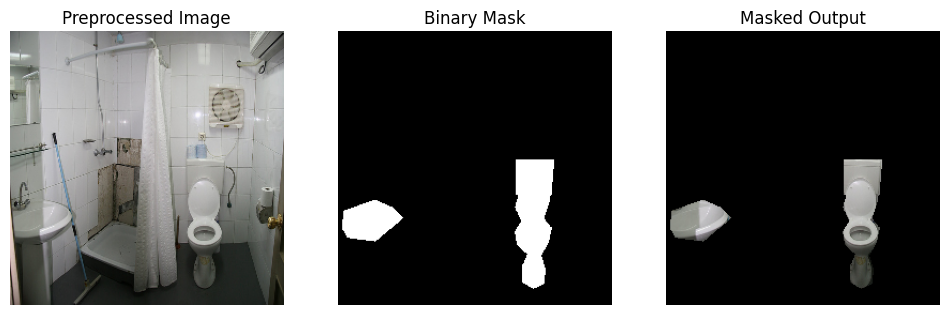

In [19]:
# Select sample image
img_id = list(coco.imgs.keys())[5]

# Preprocess
image, mask = preprocess_sample(img_id)

# Apply mask to image
isolated = image.copy()
isolated[mask == 0] = 0

# Plot results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Preprocessed Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(isolated)
plt.title("Masked Output")
plt.axis("off")

plt.show()

In [20]:
def horizontal_flip(image, mask):
    image_flipped = np.fliplr(image)
    mask_flipped = np.fliplr(mask)
    return image_flipped, mask_flipped

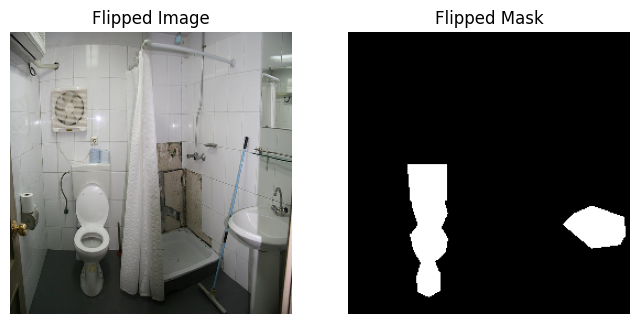

In [21]:
# Apply augmentation
img_flip, mask_flip = horizontal_flip(image, mask)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img_flip)
plt.title("Flipped Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask_flip, cmap='gray')
plt.title("Flipped Mask")
plt.axis("off")

plt.show()

In [22]:
def adjust_brightness(image, factor=1.2):
    """
    Increase or decrease brightness
    factor > 1 → brighter
    factor < 1 → darker
    """
    image = np.clip(image * factor, 0, 1)
    return image

In [23]:
def rotate_image_mask(image, mask, angle=15):
    """
    Rotate image and mask by given angle
    """
    h, w = image.shape[:2]
    center = (w // 2, h // 2)

    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)

    image_rotated = cv2.warpAffine(image, matrix, (w, h))
    mask_rotated = cv2.warpAffine(mask, matrix, (w, h), flags=cv2.INTER_NEAREST)

    return image_rotated, mask_rotated

In [24]:
def random_zoom(image, mask, zoom_factor=0.8):
    """
    Zoom-in augmentation
    """
    h, w = image.shape[:2]
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)

    start_x = (w - new_w) // 2
    start_y = (h - new_h) // 2

    image_crop = image[start_y:start_y+new_h, start_x:start_x+new_w]
    mask_crop = mask[start_y:start_y+new_h, start_x:start_x+new_w]

    image_zoomed = cv2.resize(image_crop, (w, h))
    mask_zoomed = cv2.resize(mask_crop, (w, h), interpolation=cv2.INTER_NEAREST)

    return image_zoomed, mask_zoomed

In [25]:
def gaussian_blur(image):
    """
    Apply Gaussian blur
    """
    return cv2.GaussianBlur(image, (5, 5), 0)

In [26]:
# Load and preprocess a sample
img_id = list(coco.imgs.keys())[10]
image, mask = preprocess_sample(img_id)

# Apply augmentations
img_flip, mask_flip = horizontal_flip(image, mask)
img_rot, mask_rot = rotate_image_mask(image, mask, angle=10)
img_zoom, mask_zoom = random_zoom(image, mask)
img_bright = adjust_brightness(image, factor=1.3)
img_blur = gaussian_blur(image)

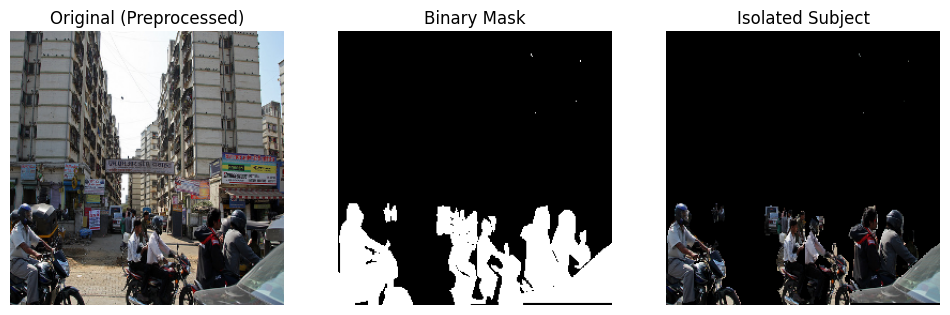

In [27]:
# Create isolated output
isolated = image.copy()
isolated[mask == 0] = 0

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original (Preprocessed)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Binary Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(isolated)
plt.title("Isolated Subject")
plt.axis("off")

plt.show()

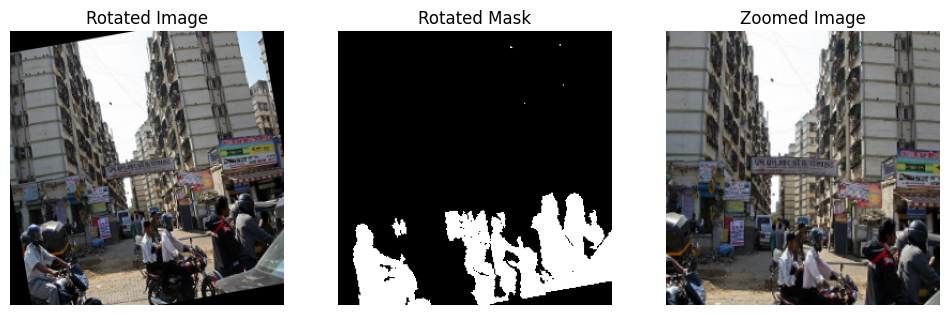

In [28]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_rot)
plt.title("Rotated Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask_rot, cmap="gray")
plt.title("Rotated Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_zoom)
plt.title("Zoomed Image")
plt.axis("off")

plt.show()

In [29]:
!pip install torch torchvision

In [30]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from pycocotools.coco import COCO

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [32]:
IMAGE_DIR = "coco/val2017"
ANNOTATION_FILE = "coco/annotations/instances_val2017.json"

coco = COCO(ANNOTATION_FILE)

# All 5000 image IDs
image_ids = list(coco.imgs.keys())
print("Total images:", len(image_ids))

loading annotations into memory...
Done (t=0.70s)
creating index...
index created!
Total images: 5000


In [33]:
# Shuffle images
np.random.seed(42)
np.random.shuffle(image_ids)

total = len(image_ids)

train_ids = image_ids[:int(0.7 * total)]
val_ids   = image_ids[int(0.7 * total):int(0.85 * total)]
test_ids  = image_ids[int(0.85 * total):]

print("Train:", len(train_ids))
print("Validation:", len(val_ids))
print("Test:", len(test_ids))

Train: 3500
Validation: 750
Test: 750


In [34]:
IMG_SIZE = 256

class CocoSegmentationDataset(Dataset):
    def __init__(self, img_ids, coco, img_dir):
        self.img_ids = img_ids
        self.coco = coco
        self.img_dir = img_dir

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]

        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))

        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 0).astype(np.float32)
        mask = torch.tensor(mask).unsqueeze(0)

        return image, mask

In [35]:
BATCH_SIZE = 8

train_dataset = CocoSegmentationDataset(train_ids, coco, IMAGE_DIR)
val_dataset   = CocoSegmentationDataset(val_ids, coco, IMAGE_DIR)
test_dataset  = CocoSegmentationDataset(test_ids, coco, IMAGE_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [36]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def CBR(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.enc1 = CBR(3, 64)
        self.enc2 = CBR(64, 128)
        self.enc3 = CBR(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = CBR(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = CBR(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = CBR(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = CBR(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return torch.sigmoid(self.final(d1))

In [37]:
model = UNet().to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [38]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, masks in tqdm(train_loader):
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

100%|██████████| 438/438 [03:19<00:00,  2.19it/s]


Epoch [1/10] | Train Loss: 0.5807 | Val Loss: 0.5407


100%|██████████| 438/438 [03:33<00:00,  2.05it/s]


Epoch [2/10] | Train Loss: 0.5422 | Val Loss: 0.5741


100%|██████████| 438/438 [03:32<00:00,  2.06it/s]


...

Epoch [8/10] | Train Loss: 0.4817 | Val Loss: 0.4859


100%|██████████| 438/438 [03:32<00:00,  2.06it/s]


Epoch [9/10] | Train Loss: 0.4719 | Val Loss: 0.4730


100%|██████████| 438/438 [03:31<00:00,  2.07it/s]


Epoch [10/10] | Train Loss: 0.4687 | Val Loss: 0.4709


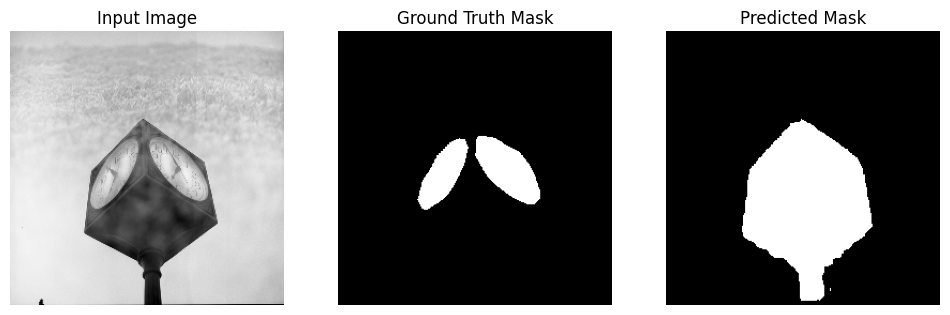

In [39]:
model.eval()
images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    preds = model(images)

image = images[0].cpu().permute(1,2,0)
mask = masks[0].cpu().squeeze()
pred = preds[0].cpu().squeeze()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred > 0.5, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [41]:
# Model is already trained in Week 3
# If restarting runtime, load saved model like this:
# model.load_state_dict(torch.load("unet_week3.pth"))

model.eval()
print("Model ready for evaluation")

Model ready for evaluation


In [42]:
def iou_score(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return intersection / (union + 1e-6)

In [43]:
def dice_score(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    return (2. * intersection) / (pred.sum() + target.sum() + 1e-6)

In [44]:
def pixel_accuracy(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    correct = (pred == target).sum()
    total = torch.numel(pred)
    return correct / total

In [45]:
iou_total, dice_total, acc_total = 0, 0, 0
count = 0

with torch.no_grad():
    for images, masks in tqdm(val_loader):
        images, masks = images.to(device), masks.to(device)
        preds = model(images)

        for i in range(images.size(0)):
            iou_total += iou_score(preds[i], masks[i])
            dice_total += dice_score(preds[i], masks[i])
            acc_total += pixel_accuracy(preds[i], masks[i])
            count += 1

print(f"Mean IoU: {iou_total/count:.4f}")
print(f"Mean Dice: {dice_total/count:.4f}")
print(f"Pixel Accuracy: {acc_total/count:.4f}")

100%|██████████| 94/94 [00:14<00:00,  6.60it/s]


Mean IoU: 0.4094
Mean Dice: 0.5446
Pixel Accuracy: 0.7684


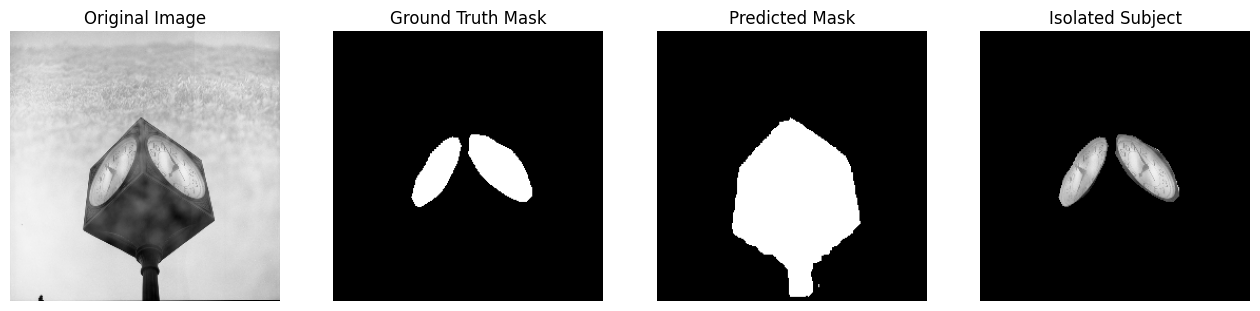

In [46]:
model.eval()
images, masks = next(iter(val_loader))
images, masks = images.to(device), masks.to(device)

with torch.no_grad():
    preds = model(images)

# Visualize first sample
img = images[0].cpu().permute(1,2,0)
gt = masks[0].cpu().squeeze()
pred = preds[0].cpu().squeeze()

# Isolated subject
isolated = img.clone()
isolated[gt == 0] = 0

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(pred > 0.5, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(isolated)
plt.title("Isolated Subject")
plt.axis("off")

plt.show()

In [47]:
class BCEDiceLoss(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = torch.nn.BCELoss()

    def forward(self, pred, target):
        bce = self.bce(pred, target)
        intersection = (pred * target).sum()
        dice = 1 - (2. * intersection) / (pred.sum() + target.sum() + 1e-6)
        return bce + dice

In [48]:
criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

EPOCHS_FINE = 5

for epoch in range(EPOCHS_FINE):
    model.train()
    loss_total = 0

    for images, masks in tqdm(train_loader):
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        loss_total += loss.item()

    print(f"Fine-Tuning Epoch {epoch+1}/{EPOCHS_FINE} | Loss: {loss_total/len(train_loader):.4f}")

100%|██████████| 438/438 [03:31<00:00,  2.07it/s]


Fine-Tuning Epoch 1/5 | Loss: 0.9176


100%|██████████| 438/438 [03:32<00:00,  2.06it/s]


Fine-Tuning Epoch 2/5 | Loss: 0.9077


100%|██████████| 438/438 [03:32<00:00,  2.06it/s]


Fine-Tuning Epoch 3/5 | Loss: 0.9033


100%|██████████| 438/438 [03:32<00:00,  2.06it/s]


Fine-Tuning Epoch 4/5 | Loss: 0.8992


100%|██████████| 438/438 [03:32<00:00,  2.06it/s]

Fine-Tuning Epoch 5/5 | Loss: 0.8955


In [49]:
iou_total, dice_total, acc_total = 0, 0, 0
count = 0

with torch.no_grad():
    for images, masks in tqdm(val_loader):
        images, masks = images.to(device), masks.to(device)
        preds = model(images)

        for i in range(images.size(0)):
            iou_total += iou_score(preds[i], masks[i])
            dice_total += dice_score(preds[i], masks[i])
            acc_total += pixel_accuracy(preds[i], masks[i])
            count += 1

print("After Fine-Tuning:")
print(f"Mean IoU: {iou_total/count:.4f}")
print(f"Mean Dice: {dice_total/count:.4f}")
print(f"Pixel Accuracy: {acc_total/count:.4f}")

100%|██████████| 94/94 [00:14<00:00,  6.61it/s]


After Fine-Tuning:
Mean IoU: 0.4275
Mean Dice: 0.5631
Pixel Accuracy: 0.7669


In [50]:
torch.save(model.state_dict(), "unet_week4_finetuned.pth")
print("Model saved successfully")

Model saved successfully


In [51]:
# Ensure model is in evaluation mode
model.eval()
print("Evaluating on TEST set")

Evaluating on TEST set


In [52]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

In [53]:
def iou_score(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return intersection / (union + 1e-6)

def dice_score(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    return (2. * intersection) / (pred.sum() + target.sum() + 1e-6)

def pixel_accuracy(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    correct = (pred == target).sum()
    total = torch.numel(pred)
    return correct / total

In [54]:
iou_total, dice_total, acc_total = 0, 0, 0
count = 0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        preds = model(images)

        for i in range(images.size(0)):
            iou_total += iou_score(preds[i], masks[i])
            dice_total += dice_score(preds[i], masks[i])
            acc_total += pixel_accuracy(preds[i], masks[i])
            count += 1

mean_iou = iou_total / count
mean_dice = dice_total / count
mean_acc = acc_total / count

print("📊 TEST SET RESULTS")
print(f"Mean IoU           : {mean_iou:.4f}")
print(f"Mean Dice Score    : {mean_dice:.4f}")
print(f"Pixel-wise Accuracy: {mean_acc:.4f}")

📊 TEST SET RESULTS
Mean IoU           : 0.4167
Mean Dice Score    : 0.5486
Pixel-wise Accuracy: 0.7691


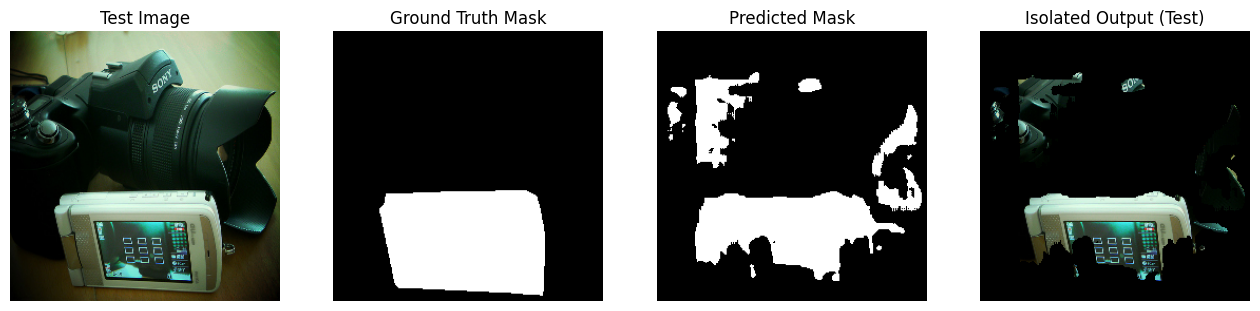

In [55]:
# Get one batch from test set
images, masks = next(iter(test_loader))
images, masks = images.to(device), masks.to(device)

with torch.no_grad():
    preds = model(images)

# Pick first image
img = images[0].cpu().permute(1,2,0)
gt = masks[0].cpu().squeeze()
pred = preds[0].cpu().squeeze()

# Isolated subject using predicted mask
isolated = img.clone()
isolated[pred <= 0.5] = 0

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(pred > 0.5, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(isolated)
plt.title("Isolated Output (Test)")
plt.axis("off")

plt.show()

In [56]:
# Write README.md file
readme_content = """# VisionExtract: Subject Isolation from Images using Image Segmentation

## Project Overview
VisionExtract is an image segmentation project aimed at automatically isolating the main subject from an image. Given an input image, the system produces an output where the subject is retained while the background is completely blacked out. This functionality is useful in photography automation, digital art, background replacement, augmented reality, and virtual conferencing.

---

## Project Objectives
- Implement semantic image segmentation for subject isolation
- Preprocess image and mask data for pixel-wise learning
- Train and fine-tune a deep learning segmentation model
- Evaluate performance using standard segmentation metrics
- Validate model generalization on unseen data

---

## Dataset
- Dataset: COCO 2017 (val2017 subset)
- Total Images Used: 5000
- Annotations: Pixel-wise segmentation masks

---

# Milestone 1: Dataset Handling and Preprocessing

## Week 1: Project Initialization and Dataset Acquisition
- Defined project objectives and expected results
- Downloaded and set up the COCO 2017 dataset
- Explored dataset structure (images, annotations, categories)
- Visualized sample images and their segmentation masks
- Verified subject isolation using mask overlays

**Outcome:** Clear understanding of dataset structure and subject-mask relationships.

---

## Week 2: Data Preprocessing and Validation
- Implemented preprocessing pipeline:
  - Image resizing (256×256)
  - Image normalization (0–1)
  - Mask resizing using nearest-neighbor interpolation
- Converted multi-class masks into binary subject-background masks
- Applied data augmentation:
  - Horizontal flipping
  - Rotation
  - Zooming
  - Brightness adjustment
  - Gaussian blur
- Validated alignment between images and masks using visual inspection

**Outcome:** Robust preprocessing pipeline ready for model training.

---

# Milestone 2: Model Training, Evaluation, and Fine-Tuning

## Week 3: Initial Model Training
- Implemented U-Net based image segmentation model
- Used all 5000 images from COCO val2017
- Dataset split:
  - 70% Training
  - 15% Validation
  - 15% Testing
- Trained model using Binary Cross-Entropy loss
- Monitored training and validation loss
- Visualized early predictions to verify learning

**Outcome:** Functional segmentation model capable of subject extraction.

---

## Week 4: Predictions and Fine-Tuning
- Generated predictions on validation data
- Compared predicted masks with ground truth masks
- Evaluated using:
  - Intersection over Union (IoU)
  - Dice Coefficient
  - Pixel-wise Accuracy
- Fine-tuned model using combined BCE + Dice loss
- Adjusted learning rate for better boundary segmentation
- Saved final fine-tuned model

**Outcome:** Improved segmentation accuracy and refined predictions.

---

## Test Set Evaluation
- Evaluated final model on unseen test dataset (15%)
- Computed IoU, Dice score, and Pixel-wise accuracy
- Visualized predictions to confirm generalization

---

## Technologies Used
- Python
- PyTorch
- OpenCV
- NumPy
- Matplotlib
- COCO API (pycocotools)
- Google Colab

---

## Project Status
- Milestone 1: Completed
- Milestone 2: Completed

---

## Author
Himanshu Ahirrao"""

with open("README.md", "w") as f:
    f.write(readme_content)

print("README.md file created successfully")

README.md file created successfully


In [57]:
from google.colab import files
files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>